# Applying SAFE Sensitivity Analysis to the OGGM

We will now apply SAFE to our scalar mass balance calibration technique to see which parameters are most sensitive.

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import scipy.stats as st

import oggm
from oggm import cfg, utils, workflow
from oggm.sandbox.edu import run_constant_climate_with_bias
from oggm.core.massbalance import mb_calibration_from_scalar_mb, apparent_mb_from_any_mb
from oggm.core import massbalance
from oggm.utils._funcs import rmsd

# Install python package for interactive visualisation and import required functions:
!pip install -q ipywidgets
from ipywidgets import interact, FloatRangeSlider, IntRangeSlider

# Install SAFE package and import required functions
!pip install SAFEpython

import safepython.RSA_thres as RSA_tr # Module that implements RSA
import safepython.plot_functions as pf # Module to visualize the results
from safepython.model_execution import model_execution # Module to execute the model
from safepython.sampling import AAT_sampling, AAT_sampling_extend # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping
from safepython.util import empiricalcdf

In [3]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='OGGM-calib-ro', reset=True)
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
oggm.cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

2025-12-19 10:43:24: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-12-19 10:43:24: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-12-19 10:43:24: oggm.cfg: Multiprocessing: using all available processors (N=22)
2025-12-19 10:43:25: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-12-19 10:43:25: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-12-19 10:43:25: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv)

In [4]:
# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

2025-12-19 10:43:28: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2025-12-19 10:43:28: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


## Step 1: One at a time sensitivity analysis

## Step 2: Global sensitivity analysis

To start with we are varying all parameters within their default ranges in the OGGM. We are then calibrating the model with all parameters (this will still only calibrate one at a time), and looking at the differences in the mean, standard deviation and the rmsd between the in-situ WGMS data and our simulated versions.

This will understand which of these parameters affect these metrics more, and we will work to quantify the uncertainty they cause. 

In [ ]:
Npop = 1000 # individual runs in the total population - TODO: Decide how many to do here, was 100,000 in the flu example
mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oggm_runner(sample_row, i):
    
    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)
    
    # Calibrate the model
    calibrated_values =  mb_calibration_from_scalar_mb(gdir_hef, 
                                         ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
                                         ref_mb_years=mbdf.index.tolist(),
                                         overwrite_gdir=True,
                                         overwrite_observations = True,
                                         calibrate_param1='prcp_fac',
                                         calibrate_param2='melt_f',
                                         calibrate_param3='temp_bias',
                                         melt_f = melt_f,
                                         prcp_fac=prcp_fac,
                                         temp_bias=temp_bias)
    
    mbmod = massbalance.MonthlyTIModel(gdir_hef)
    fls = gdir_hef.read_pickle('inversion_flowlines')
    mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)

    mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    mean_diff = np.array(mbdf['mod_mb'].mean() - mbdf['in_situ_mb'].mean())
    std_diff = np.array(mbdf['mod_mb'].std() - mbdf['in_situ_mb'].std())
    rmsd_ = np.array(rmsd(mbdf['mod_mb'], mbdf['in_situ_mb']))
    
    return [mean_diff, std_diff, rmsd_][i]

# Define input variability space:
X_Labels = ['melt_f', 'prcp_fac', 'temp_bias'] # Name of parameters (used to customize plots) - standard as to what we are currently calibrating with the scalar mb function
M = len(X_Labels) # Number of parameters
distr_fun = st.uniform # Parameter distributions
xmin = [1.5, 0.1, -15] # Parameter ranges (lower bound) - currently as the standard in OGGM
xmax = [17, 10, 15] # Parameter ranges (upper bound) - currently as the standard in OGGM
# Save lower and upper bound in the appropriate format to be passed on to the sampling function:
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [xmin[i], xmax[i] - xmin[i]]
samp_strat = 'lhs' # sampling strategy (options: 'lhs' = Latin Hypercube sampling,'rsu' = Random uniform sampling)
N = 3000 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Perform sampling
# Execute the model against all the samples in 'X':
Y1 = model_execution(oggm_runner, X, 0) # mean_diff
Y2 = model_execution(oggm_runner, X, 1) # std_diff
Y3 = model_execution(oggm_runner, X, 2) # rmsd

# check volume, mean mb and runoff?

2025-12-19 11:39:16: oggm.cfg: PARAMS['melt_f'] changed from `10.58841266655276` to `6.675062523877183`.
2025-12-19 11:39:16: oggm.cfg: PARAMS['prcp_fac'] changed from `9.315023417288918` to `9.2967796851753`.
2025-12-19 11:39:16: oggm.cfg: PARAMS['temp_bias'] changed from `-1.9561746271974148` to `9.232545785516127`.
2025-12-19 11:39:17: oggm.cfg: PARAMS['melt_f'] changed from `6.675062523877183` to `16.873039215623724`.
2025-12-19 11:39:17: oggm.cfg: PARAMS['prcp_fac'] changed from `9.2967796851753` to `9.10881201558901`.
2025-12-19 11:39:17: oggm.cfg: PARAMS['temp_bias'] changed from `9.232545785516127` to `3.6724566529779956`.
2025-12-19 11:39:17: oggm.cfg: PARAMS['melt_f'] changed from `16.873039215623724` to `5.6303603003027645`.
2025-12-19 11:39:17: oggm.cfg: PARAMS['prcp_fac'] changed from `9.10881201558901` to `6.336296803659581`.
2025-12-19 11:39:17: oggm.cfg: PARAMS['temp_bias'] changed from `3.6724566529779956` to `-10.819694902036257`.
2025-12-19 11:39:17: oggm.cfg: PARAMS

(Text(0.5, 0, 'mean diff'), Text(0, 0.5, 'rmsd'))

<Figure size 1300x1200 with 0 Axes>

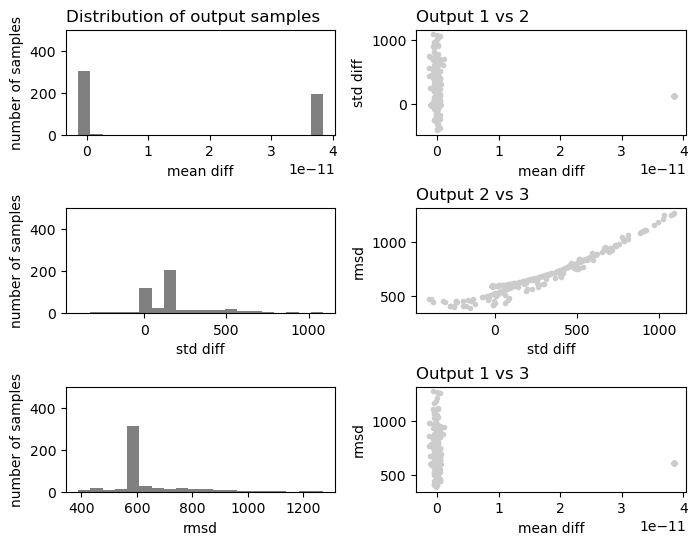

In [55]:
# Plot frequency distribution of outputs:
Y_Labels = ['mean diff','std diff', 'rmsd'] 

plt.figure(figsize=[13,12])
fig,axes = plt.subplots(3, 2, figsize = (8,6))
plt.subplots_adjust(hspace=0.7, wspace=0.3)

axes[0,0].set_title('Distribution of output samples', loc='left')
axes[0,0].hist(Y1, bins=20, color='grey');
# plt.axvline(x=target1, color='r'), 
axes[0,0].set_ylim((0,N))
axes[0,0].set_ylabel('number of samples')
axes[0,0].set_xlabel(Y_Labels[0])

axes[1,0].hist(Y2, bins=20, color='grey')
# , plt.axvline(x=target2, color='r')
axes[1,0].set_ylim((0,N))
axes[1,0].set_xlabel(Y_Labels[1])
axes[1,0].set_ylabel('number of samples')
axes[2,0].hist(Y3, bins=20, color='grey')
# , plt.axvline(x=target2, color='r')
axes[2,0].set_ylim((0,N)), axes[2,0].set_xlabel(Y_Labels[2])
axes[2,0].set_ylabel('number of samples')

axes[0,1].set_title('Output 1 vs 2', loc='left')
axes[0,1].plot(Y1,Y2, '.', markerfacecolor='0.8', markeredgecolor='0.8')
axes[0,1].set_xlabel(Y_Labels[0]), axes[0,1].set_ylabel(Y_Labels[1])

axes[1,1].set_title('Output 2 vs 3', loc='left')
axes[1,1].plot(Y2,Y3, '.', markerfacecolor='0.8', markeredgecolor='0.8')
axes[1,1].set_xlabel(Y_Labels[1]), axes[1,1].set_ylabel(Y_Labels[2])


axes[2,1].set_title('Output 1 vs 3', loc='left')
axes[2,1].plot(Y1,Y3, '.', markerfacecolor='0.8', markeredgecolor='0.8')
axes[2,1].set_xlabel(Y_Labels[0]), axes[2,1].set_ylabel(Y_Labels[2])


This provides quite a bit of insight, but the mean_diff that is arounf 4e-11 is making it hard for us to read the graphs on the RHS. I am going to remove this to see if there are any more obvious trends.

(Text(0.5, 0, 'mean diff'), Text(0, 0.5, 'rmsd'))

<Figure size 1300x1200 with 0 Axes>

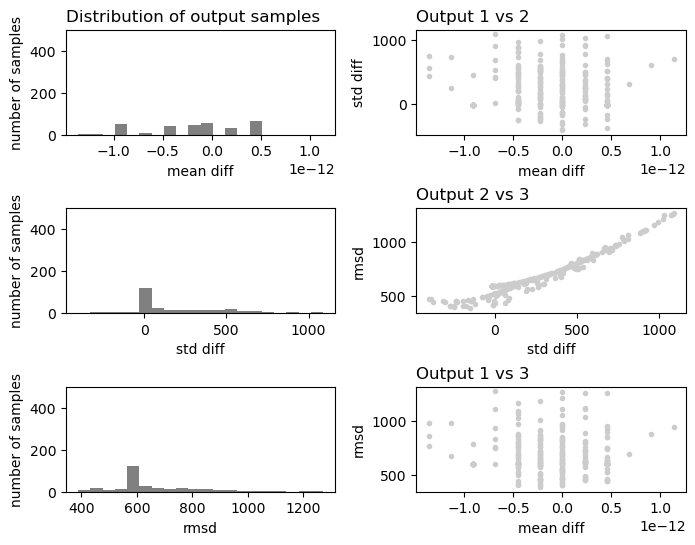

In [56]:
# Find indices to delete (rows where condition is True)
to_delete = np.where(Y1 > 3e-11)[0]

# Delete those rows from each array (axis=0 = row)
X_clean  = np.delete(X,  to_delete, axis=0)
Y1_clean = np.delete(Y1, to_delete, axis=0)
Y2_clean = np.delete(Y2, to_delete, axis=0)
Y3_clean = np.delete(Y3, to_delete, axis=0)

# Plot frequency distribution of outputs:
Y_Labels = ['mean diff','std diff', 'rmsd'] 

plt.figure(figsize=[13,12])
fig,axes = plt.subplots(3, 2, figsize = (8,6))
plt.subplots_adjust(hspace=0.7, wspace=0.3)

axes[0,0].set_title('Distribution of output samples', loc='left')
axes[0,0].hist(Y1_clean, bins=20, color='grey');
# plt.axvline(x=target1, color='r'), 
axes[0,0].set_ylim((0,N))
axes[0,0].set_ylabel('number of samples')
axes[0,0].set_xlabel(Y_Labels[0])

axes[1,0].hist(Y2_clean, bins=20, color='grey')
# , plt.axvline(x=target2, color='r')
axes[1,0].set_ylim((0,N))
axes[1,0].set_xlabel(Y_Labels[1])
axes[1,0].set_ylabel('number of samples')
axes[2,0].hist(Y3_clean, bins=20, color='grey')
# , plt.axvline(x=target2, color='r')
axes[2,0].set_ylim((0,N)), axes[2,0].set_xlabel(Y_Labels[2])
axes[2,0].set_ylabel('number of samples')

axes[0,1].set_title('Output 1 vs 2', loc='left')
axes[0,1].plot(Y1_clean,Y2_clean, '.', markerfacecolor='0.8', markeredgecolor='0.8')
axes[0,1].set_xlabel(Y_Labels[0]), axes[0,1].set_ylabel(Y_Labels[1])

axes[1,1].set_title('Output 2 vs 3', loc='left')
axes[1,1].plot(Y2_clean,Y3_clean, '.', markerfacecolor='0.8', markeredgecolor='0.8')
axes[1,1].set_xlabel(Y_Labels[1]), axes[1,1].set_ylabel(Y_Labels[2])


axes[2,1].set_title('Output 1 vs 3', loc='left')
axes[2,1].plot(Y1_clean,Y3_clean, '.', markerfacecolor='0.8', markeredgecolor='0.8')
axes[2,1].set_xlabel(Y_Labels[0]), axes[2,1].set_ylabel(Y_Labels[2])

## Analysing Monte Carlo samples to quantify the output uncertainty

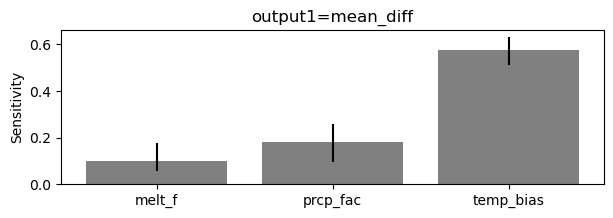

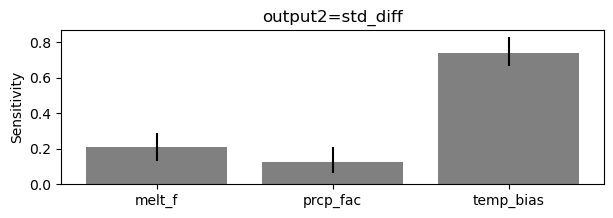

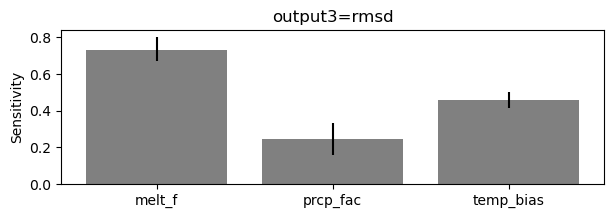

In [57]:
mvd_m_list1 = []

Nboot = 100 # Number of resamples used for bootstrapping
Y_Labels = ['output1=mean_diff','output2=std_diff','output3=rmsd']
for i in range(3):
    if i==0:
        Y=Y1
        target=0
    if i==1:
        Y=Y2
        target=0
    if i==2:
        Y=Y3
        target=500 # Ideally this would be 0, but we are minimising the mean and this is the threshold that works
    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    mvd_m_list1.append(mvd_m)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_Labels), plt.ylabel('Sensitivity')
    plt.show()

    # Are targets correct here? We want them to be as close as possible, not greater than/less than etc

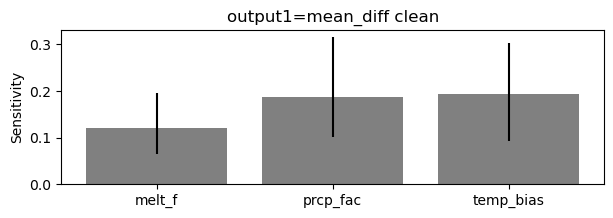

In [58]:
Nboot = 100 # Number of resamples used for bootstrapping
Y_Labels = ['output1=mean_diff clean']
Y=Y1_clean
target=0

plt.figure(figsize=[7,2])
mvd, _, _, idx = RSA_tr.RSA_indices_thres(X_clean, Y, target, Nboot=Nboot)
mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
plt.title(Y_Labels[0], loc='center'), plt.xticks(range(len(mvd_m)), X_Labels), plt.ylabel('Sensitivity')
plt.show()

Adding a seaborn heatmap pattern plot

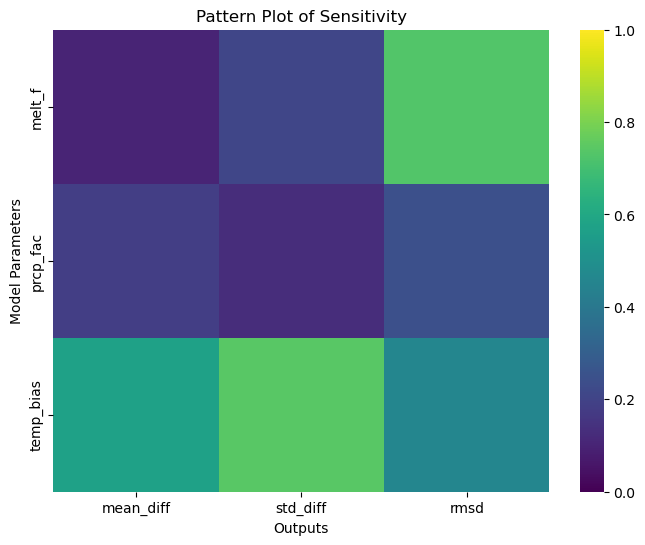

[array([0.10040111, 0.18095238, 0.57361948]),
 array([0.21087174, 0.12640328, 0.73963825]),
 array([0.73028269, 0.24589236, 0.45857821])]

In [59]:
import seaborn as sns
import pandas as pd

# Labels
param_labels = ['melt_f', 'prcp_fac', 'temp_bias']
metric_labels = ['mean_diff', 'std_diff', 'rmsd']

sensitivity_matrix = pd.DataFrame(mvd_m_list1, columns=metric_labels, index=param_labels).T

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(sensitivity_matrix, cmap='viridis', cbar=True,
            xticklabels=metric_labels, yticklabels=param_labels,
            vmin=0, vmax=1, fmt=".1f")  # white to red scale
plt.xlabel('Outputs')
plt.ylabel('Model Parameters')
plt.title('Pattern Plot of Sensitivity')
plt.show()

mvd_m_list1

TODO: Update this when running more runs

All of the uncertainties here seem relatively large, especially when considering the differences in the mean mass balance and the differences in the standard deviation.

The uncertainties in the rmsd actually seem lower here.

For the mean and standard deviation, the most sensitive parameter is the temp_bias, this is likely due to the wide range for which the temperature bias is, this is by default in the OGGM set to be [-15,15] where as the melt is [1.5, 17] and the precipitation factor is [0.1,10] which all have a smaller range of values.

We have explored some metrics that are quite simple, we have other benchmarks that we can measure. We will now look into the implications of changing these parameters on our runoff and volume.

In [13]:
from oggm import tasks
import xarray as xr

Npop = 10000 # individual runs in the total population - TODO: Decide how many to do here, was 100,000 in the flu example
Nday = 100
t = np.linspace(1,Nday,Nday)

mbdf = gdir_hef.get_ref_mb_data().loc[2000:2019] # WGMS data for HEF

def oggm_runner(sample_row, i):
    
    # Set the values
    melt_f, prcp_fac, temp_bias = sample_row
    cfg.PARAMS['melt_f'] = float(melt_f)
    cfg.PARAMS['prcp_fac'] = float(prcp_fac)
    cfg.PARAMS['temp_bias'] = float(temp_bias)
    
    # Calibrate the model
    calibrated_mb = mb_calibration_from_scalar_mb(gdir_hef, 
                                         ref_mb=mbdf['ANNUAL_BALANCE'].mean(),
                                         ref_mb_years=mbdf.index.tolist(),
                                         overwrite_gdir=True,
                                         overwrite_observations = True,
                                         calibrate_param1='prcp_fac',
                                         calibrate_param2='melt_f',
                                         calibrate_param3='temp_bias',
                                         melt_f = melt_f,
                                         prcp_fac=prcp_fac,
                                         temp_bias=temp_bias)
    
    # # Adding the mass balance model with the new calibration
    # mbmod = massbalance.MonthlyTIModel(gdir_hef)
    # fls = gdir_hef.read_pickle('inversion_flowlines')
    # mbdf['mod_mb'] = mbmod.get_specific_mb(fls=fls, year=mbdf.index)
    # # mean_mb = np.array(mbdf['mod_mb'].mean())
    # mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[2000:2019]['ANNUAL_BALANCE']

    # print(np.array(repr(mbdf['mod_mb'].mean())))
    # mean_mb = np.array(float(repr(mbdf['mod_mb'].mean())))

    file_id = "_mod"

    # Then calculate runoff
    tasks.run_with_hydro(gdir_hef,  # Run on the selected glacier
                     run_task=tasks.run_from_climate_data,  # running from observed climate data
                     ys=2000,  # Period which we will average and constantly repeat
                     init_model_yr=2000, # Start from spinup year 2000
                     init_model_filesuffix='_spinup_historical',  # use the previous run as initial state
                     store_monthly_hydro=True,  # Monthly ouptuts provide additional information
                     output_filesuffix=file_id);  # an identifier for the output file, to read it later
    
    # Then calculate the volume
    with xr.open_dataset(gdir_hef.get_filepath('model_diagnostics', filesuffix=file_id)) as ds:
    # The last step of hydrological output is NaN (we can't compute it for this year)
        ds = ds.isel(time=slice(0, -1)).load()

    # These summed variabels give the total runoff from the glacier
    runoff_vars = ['melt_off_glacier', 'melt_on_glacier','liq_prcp_off_glacier', 'liq_prcp_on_glacier']

    # Plot the runoff again for the calibrated melt_f parameter
    sel_vars = [v for v in ds.variables if 'month_2d' not in ds[v].dims]
    df_annual = ds[sel_vars].to_dataframe()

    df_runoff = np.array((((df_annual[runoff_vars] * 1e-9).sum(axis=1))).mean())
    # 1) Apparent MB must be recomputed with the newly calibrated parameters

    tasks.apparent_mb_from_any_mb(gdir_hef)

    # 3) Inversion: prepare and compute thickness / volume
    tasks.prepare_for_inversion(gdir_hef)
    tasks.mass_conservation_inversion(gdir_hef)

    # 4) Read volume (m³) and convert to km³
    try:
        vol_m3 = tasks.get_inversion_volume(gdir_hef)  # returns total inversion volume
    except Exception:
        # Robust fallback: integrate over inversion flowlines
        fls = gdir_hef.read_pickle('inversion_flowlines')
        vol_m3 = sum(np.sum(fl.thick * fl.width_m * fl.dx) for fl in fls)

    vol_km3 = np.array(float(vol_m3) / 1e9)
    return [vol_km3, df_runoff][i]

# Define input variability space:
X_Labels = ['melt_f', 'prcp_fac', 'temp_bias'] # Name of parameters (used to customize plots) - standard as to what we are currently calibrating with the scalar mb function
M = len(X_Labels) # Number of parameters
distr_fun = st.uniform # Parameter distributions
xmin = [1.5, 0.1, -15] # Parameter ranges (lower bound) - currently as the standard in OGGM
xmax = [17, 10, 15] # Parameter ranges (upper bound) - currently as the standard in OGGM
# Save lower and upper bound in the appropriate format to be passed on to the sampling function:
distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [xmin[i], xmax[i] - xmin[i]]
samp_strat = 'lhs' # sampling strategy (options: 'lhs' = Latin Hypercube sampling,'rsu' = Random uniform sampling)
N = 2000 # Number of samples
X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Perform sampling

# Checking volume, Mean MB and Runoff
# Execute the model against all the samples in 'X':
Y1 = model_execution(oggm_runner, X, 0) # volume
# Y2 = model_execution(oggm_runner, X, 1) # mean mb
Y2 = model_execution(oggm_runner, X, 1) # runoff

2025-12-17 11:48:01: oggm.cfg: PARAMS['melt_f'] changed from `14.731626776625781` to `15.083361421000898`.
2025-12-17 11:48:01: oggm.cfg: PARAMS['prcp_fac'] changed from `1.374484240715367` to `6.340761991520759`.
2025-12-17 11:48:01: oggm.cfg: PARAMS['temp_bias'] changed from `-8.251316200046308` to `7.518175193878001`.
2025-12-17 11:48:02: oggm.cfg: PARAMS['melt_f'] changed from `15.083361421000898` to `6.877338316040904`.
2025-12-17 11:48:02: oggm.cfg: PARAMS['prcp_fac'] changed from `6.340761991520759` to `5.894940957620961`.
2025-12-17 11:48:02: oggm.cfg: PARAMS['temp_bias'] changed from `7.518175193878001` to `-3.0093702016920982`.
2025-12-17 11:48:03: oggm.cfg: PARAMS['melt_f'] changed from `6.877338316040904` to `3.839444162035392`.
2025-12-17 11:48:03: oggm.cfg: PARAMS['prcp_fac'] changed from `5.894940957620961` to `5.698135078693419`.
2025-12-17 11:48:03: oggm.cfg: PARAMS['temp_bias'] changed from `-3.0093702016920982` to `0.7420834351467995`.
2025-12-17 11:48:03: oggm.cfg: 

(Text(0.5, 0, 'volume'), Text(0, 0.5, 'runoff'))

<Figure size 1300x1200 with 0 Axes>

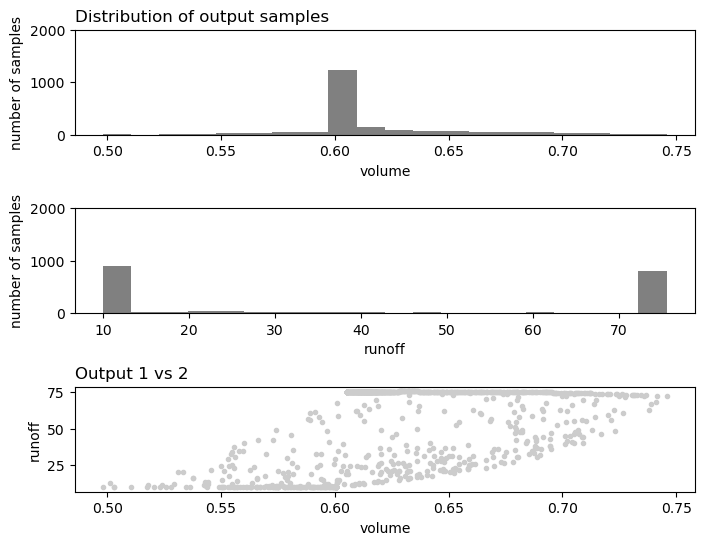

In [25]:
# Plot frequency distribution of outputs:
Y_Labels = ['volume','runoff'] 

plt.figure(figsize=[13,12])
fig,axes = plt.subplots(3, 1, figsize = (8,6))
plt.subplots_adjust(hspace=0.7, wspace=0.3)

axes[0].set_title('Distribution of output samples', loc='left')
axes[0].hist(Y1, bins=20, color='grey');
# plt.axvline(x=target1, color='r'), 
axes[0].set_ylim((0,N))
axes[0].set_ylabel('number of samples')
axes[0].set_xlabel(Y_Labels[0])

axes[1].hist(Y2, bins=20, color='grey')
# , plt.axvline(x=target2, color='r')
axes[1].set_ylim((0,N))
axes[1].set_ylabel('number of samples')
axes[1].set_xlabel(Y_Labels[1])

axes[2].set_title('Output 1 vs 2', loc='left')
axes[2].plot(Y1,Y2, '.', markerfacecolor='0.8', markeredgecolor='0.8')
axes[2].set_xlabel(Y_Labels[0]), axes[2].set_ylabel(Y_Labels[1])
# , plt.axvline(x=target1, color='r')
# plt.axhline(y=target2/10000, color='r')


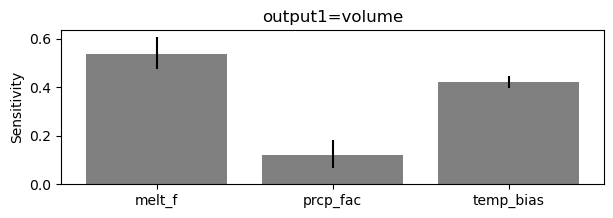

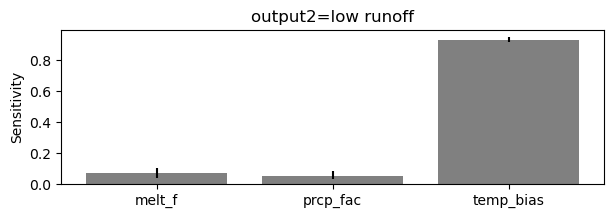

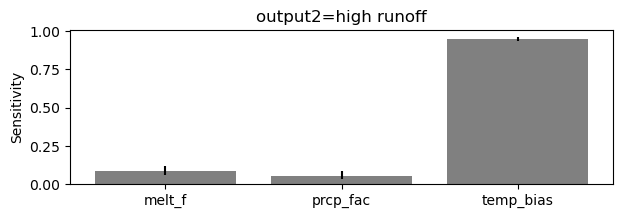

In [43]:
# The runoff appears to be a bimodal distribution
# We will consider two cases here for sensitivity analysis: one with low runoff, one with high runoff
mvd_m_list = []
Nboot = 500 # Number of resamples used for bootstrapping
Y_Labels = ['output1=volume', 'output2=low runoff', 'output2=high runoff']
for i in range(3):
    if i==0:
        Y=Y1
        target=0.6
    if i==1:
        Y=Y2
        target=15
    if i==2:
        Y=Y2
        target=75
    # plot:
    plt.figure(figsize=[7,2])
    mvd, _, _, idx = RSA_tr.RSA_indices_thres(X, Y, target, Nboot=Nboot)
    mvd_m, mvd_lb, mvd_ub = aggregate_boot(mvd) # shape (M,)
    yerr=np.c_[mvd_m-mvd_lb,mvd_ub-mvd_m].T
    mvd_m_list.append(mvd_m)
    plt.bar(range(len(mvd_m)), mvd_m, color='grey',yerr=yerr)
    plt.title(Y_Labels[i], loc='center'), plt.xticks(range(len(mvd_m)), X_Labels), plt.ylabel('Sensitivity')
    plt.show()

Adding Seaborn pattern plots.

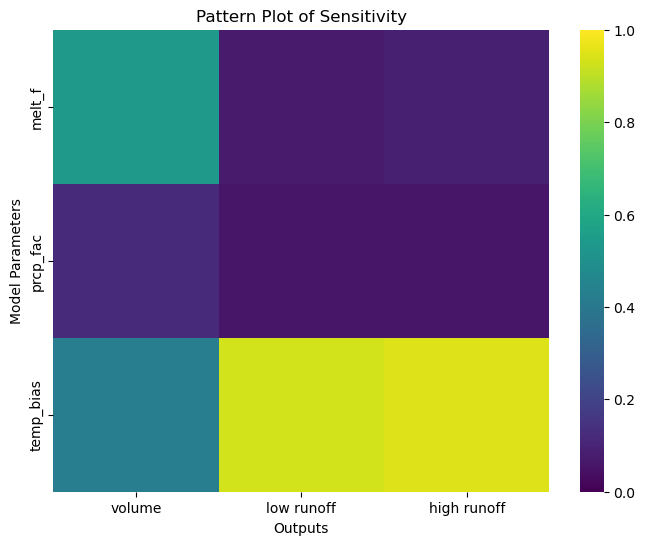

[array([0.53520025, 0.11935046, 0.42122448]),
 array([0.07158155, 0.05512787, 0.93159663]),
 array([0.08671001, 0.05548926, 0.9462322 ])]

In [52]:
import seaborn as sns
import pandas as pd

# Labels
param_labels = ['melt_f', 'prcp_fac', 'temp_bias']
metric_labels = ['volume', 'low runoff', 'high runoff']

sensitivity_matrix = pd.DataFrame(mvd_m_list, columns=metric_labels, index=param_labels).T

# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(sensitivity_matrix, cmap='viridis', cbar=True,
            xticklabels=metric_labels, yticklabels=param_labels,
            vmin=0, vmax=1, fmt=".1f")  # white to red scale
plt.xlabel('Outputs')
plt.ylabel('Model Parameters')
plt.title('Pattern Plot of Sensitivity')
plt.show()

mvd_m_list